In [1]:
!pip install insightface onnxruntime-gpu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 12.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.0/277.0 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 42.7 MB/s eta 0:00:00
  Created wheel for insightface: filename=insightface-0.7.3-cp312-cp312-linux_x86_64.whl size=1071484 sha256=68a798db197214a35bbce4394b8fe329725c24c1281cb48fc70c4d59041aa4f1
  Stored in directory: /root/.cache/pip/wheels/73/3c/e2/6d4815e8a8b33a2006554d65ce0d1f973e768f4c7a222fa675
Successfully built insightface


In [2]:
import cv2
import numpy as np
import os
from insightface.app import FaceAnalysis
from insightface.utils import face_align

In [3]:
# Khởi tạo RetinaFace và ArcFace thông qua InsightFace App
app = FaceAnalysis(name='buffalo_s', allowed_modules=['detection', 'recognition'],
                   providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
app.prepare(ctx_id=0, det_size=(640, 640))

# Lấy model gốc từ InsightFace
det_model = app.models['detection']
rec_model = app.models['recognition']

class RetinaFace:
    def detect(self, img, threshold=0.5):
        # THÊM PADDING: Giúp xử lý trường hợp mặt quá to chiếm hết ảnh
        """
        Thay đổi det_size: Tăng kích thước ảnh đầu vào cho detector.
        Thêm Padding: Tự động thêm một khoảng trắng xung quanh ảnh trước khi đưa vào nhận diện để làm khuôn mặt trông 'nhỏ lại' so với tổng thể.
        """
        h, w = img.shape[:2]
        pad_h, pad_w = h // 4, w // 4
        padded_img = cv2.copyMakeBorder(img, pad_h, pad_h, pad_w, pad_w, cv2.BORDER_CONSTANT, value=[0, 0, 0])

        # SỬA LỖI: Gán ngưỡng trực tiếp vào thuộc tính của model
        # thay vì truyền vào kwargs của hàm detect()
        det_model.det_thresh = threshold

        # Gọi hàm detect và đặt max_num=0 để tìm toàn bộ khuôn mặt trong ảnh
        bboxes, landmarks = det_model.detect(padded_img, max_num=0)

        # Xử lý trường hợp không tìm thấy khuôn mặt
        if bboxes is None or len(bboxes) == 0:
            return [], []

        # Đưa tọa độ về lại hệ tọa độ gốc của ảnh chưa pad
        bboxes[:, [0, 2]] -= pad_w
        bboxes[:, [1, 3]] -= pad_h
        landmarks -= np.array([pad_w, pad_h])

        return bboxes, landmarks

class ArcFace:
    def align_and_extract(self, img, landmark):
        aligned_face = face_align.norm_crop(img, landmark=landmark)
        embedding = rec_model.get_feat(aligned_face).flatten()
        # Chuẩn hóa vector lên mặt cầu L2 (L2 Normalization)
        normed_embedding = embedding / np.linalg.norm(embedding)
        return normed_embedding

def cosine_similarity(emb1, emb2):
    return np.dot(emb1, emb2)

def draw_result(frame, bbox, identity, sim):
    # bbox có 5 giá trị: [x1, y1, x2, y2, det_score]
    x1, y1, x2, y2 = bbox[:4].astype(int)

    cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
    # CHỈ hiển thị kết quả nhận diện và độ tương đồng (Sim)
    cv2.putText(frame, f'{identity} ({sim:.2f})', (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (36,255,12), 2)

# KHỞI TẠO LẠI ĐỂ CẬP NHẬT CLASS
detector = RetinaFace()
recognizer = ArcFace()

download_path: /root/.insightface/models/buffalo_s


100%|██████████| 124617/124617 [00:02<00:00, 49717.84KB/s]


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /root/.insightface/models/buffalo_s/1k3d68.onnx landmark_3d_68
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /root/.insightface/models/buffalo_s/2d106det.onnx landmark_2d_106
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_s/det_500m.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /root/.insightface/models/buffalo_s/genderage.onnx genderage
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_s/w600k_mbf.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)


In [4]:
def get_largest_face_idx(bboxes):
    if len(bboxes) == 0:
        return -1
    # Tính diện tích: (x2 - x1) * (y2 - y1)
    areas = (bboxes[:, 2] - bboxes[:, 0]) * (bboxes[:, 3] - bboxes[:, 1])
    return np.argmax(areas) # Trả về index của mặt to nhất

In [5]:
def create_database_from_train(train_path):
    database = {}
    # Lấy danh sách tên các thư mục (tên người)
    person_names = [d for d in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, d))]

    for name in person_names:
        person_dir = os.path.join(train_path, name)
        embeddings = []

        for root, dirs, files in os.walk(person_dir):
            for img_name in files:
                if not img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    continue

                img = cv2.imread(os.path.join(root, img_name))
                if img is None: continue

                # # Trích xuất khuôn mặt bằng FaceAnalysis app
                # faces = app.get(img)
                # for face in faces:
                #     # Thêm embedding đã được chuẩn hóa sẵn từ InsightFace
                #     embeddings.append(face.normed_embedding)

                # 1. Phát hiện tất cả khuôn mặt
                bboxes, landmarks = detector.detect(img)

                # 2. Lọc bỏ nhiễu, CHỈ lấy mặt lớn nhất
                if len(bboxes) > 0:
                    best_idx = get_largest_face_idx(bboxes)
                    # 3. Trích xuất đúng 1 mặt đó
                    emb = recognizer.align_and_extract(img, landmarks[best_idx])
                    embeddings.append(emb)

        # Sau khi duyệt hết ảnh của một người, tính vector trung bình
        if len(embeddings) > 0:
            mean_emb = np.mean(embeddings, axis=0)
            # BẮT BUỘC: Chuẩn hóa lại vector trung bình để đưa nó về độ dài 1 (unit vector)
            norm_mean_emb = mean_emb / np.linalg.norm(mean_emb)
            database[name] = norm_mean_emb
            print(f"Đã thêm {name} vào database với {len(embeddings)} khuôn mặt.")

    # Lưu database để sử dụng sau này
    np.save("face_database.npy", database)
    return database

In [6]:
def evaluate_model(test_path, database, threshold=0.4):
    from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix
    import seaborn as sns
    import matplotlib.pyplot as plt
    import os
    import cv2
    import numpy as np

    y_true = []
    y_pred = []

    person_names = sorted([d for d in os.listdir(test_path) if os.path.isdir(os.path.join(test_path, d))])

    print("Đang bắt đầu đánh giá...")
    for name in person_names:
        person_dir = os.path.join(test_path, name)
        for root, dirs, files in os.walk(person_dir):
            for img_name in files:
                if not img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    continue

                img = cv2.imread(os.path.join(root, img_name))
                if img is None: continue

                # 1. Nhận diện mặt (Chỉ gọi 1 lần duy nhất)
                bboxes, landmarks = detector.detect(img, threshold=0.5)

                # 2. Xử lý logic đồng bộ cho y_true và y_pred
                if len(bboxes) == 0:
                    # Không tìm thấy mặt: Ground Truth vẫn là name, nhưng dự đoán là Unknown
                    y_true.append(name)
                    y_pred.append("Unknown")
                else:
                    # Tìm thấy mặt: Lấy mặt lớn nhất
                    best_idx = get_largest_face_idx(bboxes)
                    current_embedding = recognizer.align_and_extract(img, landmarks[best_idx])

                    max_sim = -1
                    identity = "Unknown"

                    for db_name, db_embed in database.items():
                        sim = np.dot(current_embedding, db_embed)
                        if sim > max_sim:
                            max_sim = sim
                            identity = db_name

                    # Kiểm tra ngưỡng
                    final_prediction = identity if max_sim >= threshold else "Unknown"

                    y_true.append(name)
                    y_pred.append(final_prediction)

    # Kiểm tra tính nhất quán trước khi in báo cáo
    if len(y_true) != len(y_pred):
        print(f"LỖI: Độ dài không khớp! True: {len(y_true)}, Pred: {len(y_pred)}")
        return None

    print(f"\n--- Báo cáo kết quả chi tiết (Tổng số mẫu: {len(y_true)}) ---")
    print(classification_report(y_true, y_pred, zero_division=0))

    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    # Vẽ Confusion Matrix
    labels = sorted(list(set(y_true + y_pred)))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return precision, recall, f1

In [7]:
def recognize_realtime(frame, database, threshold=0.4):
    # 1. Tìm tất cả mặt trong frame bằng RetinaFace
    bboxes, landmarks = detector.detect(frame)

    for bbox, landmark in zip(bboxes, landmarks):
        # 2. Align và trích xuất embedding cho khuôn mặt hiện tại
        # SỬA LỖI: Truyền 'frame' thay vì 'bboxes' vào hàm align
        current_embedding = recognizer.align_and_extract(frame, landmark)

        # 3. So khớp với Database (Cosine Similarity)
        identity = "Unknown"
        max_sim = -1

        for name, saved_embedding in database.items():
            sim = cosine_similarity(current_embedding, saved_embedding)
            if sim > max_sim:
                max_sim = sim
                identity = name

        # 4. Kiểm tra ngưỡng (Threshold)
        if max_sim < threshold: identity = "Unknown"

        # 5. Vẽ kết quả
        draw_result(frame, bbox, identity, max_sim)

In [8]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [9]:
dataset_path = "/content/drive/MyDrive/Colab_Notebooks/AI/Datasets/CS231_Dataset_Final.zip"

folder = "/content/Face"
!unzip -q $dataset_path -d $folder

In [10]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Capture to be clicked.
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getTracks().forEach(track => track.stop());
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename

In [11]:
# # Đường dẫn gốc tới dataset
# root_path = "/content/Face/CS231_Dataset_Final"
# train_path = os.path.join(root_path, "train")
# val_path = os.path.join(root_path, "val")
# test_path = os.path.join(root_path, "test")

# # 1. Tạo database từ tập Train
# database = create_database_from_train(train_path)

# import numpy as np
# import os

# # Thư mục lưu trữ
# save_dir = "/content"
# file_path = os.path.join(save_dir, "face_database.npy")

# # Sử dụng np.save để lưu dictionary database
# # Lưu ý: database phải là biến đã được định nghĩa từ các bước trước
# np.save(file_path, database)

# print(f"Đã lưu database thành công tại: {file_path}")

In [13]:
# Tải database embeddings
database = np.load("face_database.npy", allow_pickle=True).item()

# Thiết lập đường dẫn đến các thư mục chứa ảnh thực tế
# Giả định folder giải nén là /content/Face/CS231_Dataset_Final
dataset_root = "/content/Face/CS231_Dataset_Final"

train_path = os.path.join(dataset_root, "train")
val_path = os.path.join(dataset_root, "val")
test_path = os.path.join(dataset_root, "test")

print(f"Database loaded with {len(database)} identities.")
print(f"Paths set to: {train_path}, {val_path}, {test_path}")

Database loaded with 5 identities.
Paths set to: /content/Face/CS231_Dataset_Final/train, /content/Face/CS231_Dataset_Final/val, /content/Face/CS231_Dataset_Final/test



--- Đánh giá trên tập VAL ---

--- Đánh giá trên tập TEST ---
Đang bắt đầu đánh giá...

--- Báo cáo kết quả chi tiết (Tổng số mẫu: 50) ---
              precision    recall  f1-score   support

         Dan       1.00      1.00      1.00        10
         Tri       1.00      1.00      1.00        10
       Triet       1.00      1.00      1.00        10
       Trieu       1.00      1.00      1.00        10
          Vi       1.00      1.00      1.00        10

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



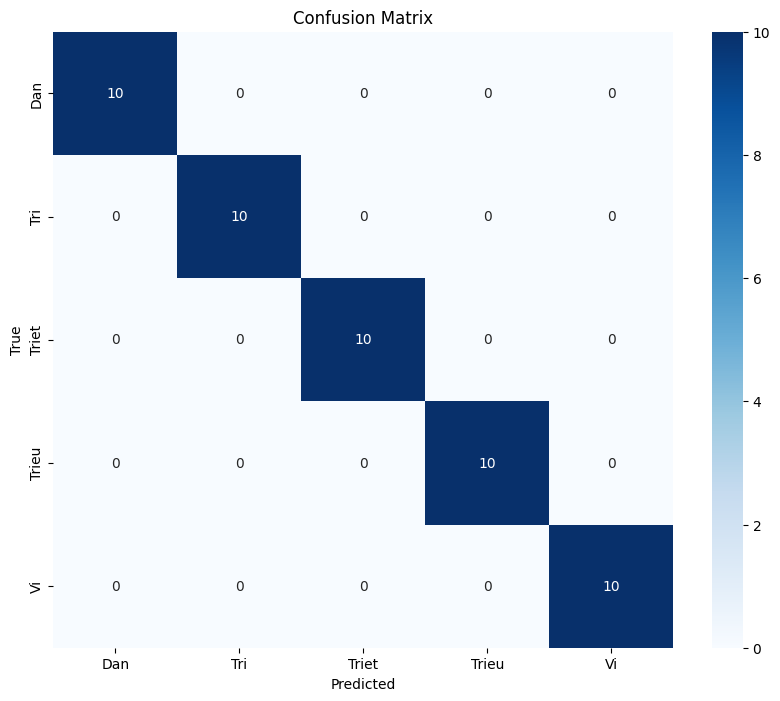

In [14]:
# 2. Đánh giá trên tập Val (để chỉnh threshold nếu cần)
print("\n--- Đánh giá trên tập VAL ---")
# evaluate_model(val_path, database, threshold=0.4)

# 3. Đánh giá trên tập Test (kết quả cuối cùng)
print("\n--- Đánh giá trên tập TEST ---")
# Đảm bảo sử dụng detector đã được sửa lỗi
precision, recall, f1 = evaluate_model(test_path, database, threshold=0.5)

In [ ]:
import matplotlib.pyplot as plt
try:
  # 2. Mở webcam và chụp ảnh
  filename = take_photo()
  print('Saved to {}'.format(filename))

  # 3. Đọc ảnh vừa chụp
  frame = cv2.imread(filename)

  # 4. Nhận diện
  recognize_realtime(frame, database)

  # 5. Hiển thị
  plt.figure(figsize=(10, 6))
  plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
  plt.axis('off')
  plt.show()

except Exception as err:
  print(str(err))

### Tải ảnh lên từ máy tính và nhận diện
Sử dụng ô dưới đây để upload file ảnh (`.jpg`, `.png`, `.jpeg`) từ máy tính của bạn.

Saving IMG_0194_f00267.jpg to IMG_0194_f00267.jpg
Đang xử lý file: IMG_0194_f00267.jpg


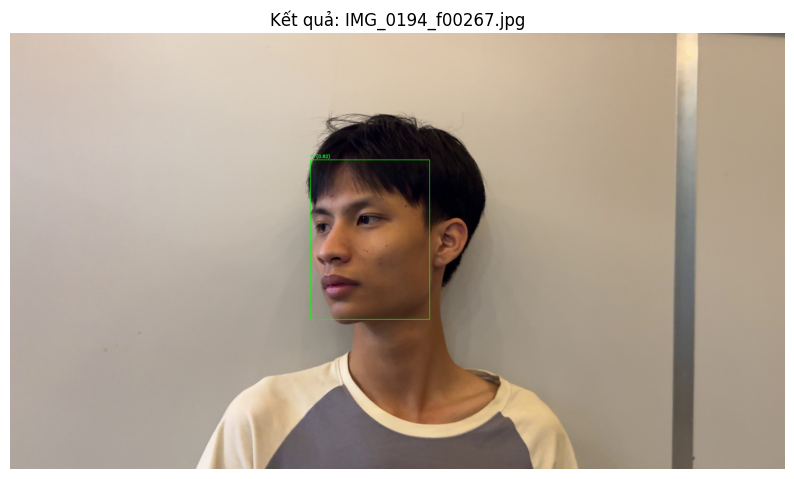

In [24]:
from google.colab import files
import matplotlib.pyplot as plt

# 1. Tải file lên
uploaded = files.upload()

for filename in uploaded.keys():
    print(f'Đang xử lý file: {filename}')

    # 2. Đọc ảnh
    frame = cv2.imread(filename)
    if frame is None:
        print(f"Không thể đọc file {filename}")
        continue

    # 3. Nhận diện (Sử dụng database đã tạo ở các bước trước)
    # Bạn có thể điều chỉnh threshold ở đây (ví dụ: threshold=0.45)
    recognize_realtime(frame, database, threshold=0.5)

    # 4. Hiển thị kết quả
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.title(f"Kết quả: {filename}")
    plt.axis('off')
    plt.show()

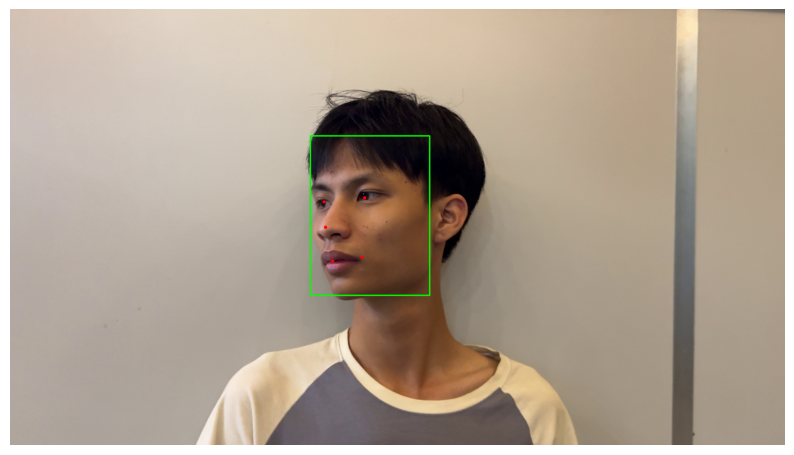

In [25]:
def visualize_detection(img_path):
    # 1. Đọc ảnh
    img = cv2.imread(img_path)
    if img is None:
        print(f"Không thể đọc ảnh tại: {img_path}")
        return
    img_display = img.copy()

    # 2. Phát hiện mặt
    bboxes, landmarks = detector.detect(img)

    if len(bboxes) > 0:
        for i in range(len(bboxes)):
            # Lấy tọa độ bbox
            x1, y1, x2, y2 = bboxes[i][:4].astype(int)

            # Con số 3 cuối cùng là độ dày (thickness) của đường viền
            # Tôi đã tăng từ 2 lên 3 để đường viền rõ hơn theo yêu cầu
            cv2.rectangle(img_display, (x1, y1), (x2, y2), (0, 255, 0), 5)

            # Vẽ 5 điểm Landmarks màu đỏ
            for pt in landmarks[i]:
                # Con số 5 dưới đây là bán kính (radius) của chấm đỏ
                # pt[0] và pt[1]: Đây là tọa độ X (ngang) và Y (dọc) của các điểm mốc trên khuôn mặt (landmarks) mà mô hình RetinaFace tìm được.
                # pt[0]: Vị trí của điểm đó tính từ lề trái ảnh.
                # pt[1]: Vị trí của điểm đó tính từ lề trên ảnh.
                cv2.circle(img_display, (int(pt[0]), int(pt[1])), 8, (0, 0, 255), -1)
    else:
        print("Không tìm thấy khuôn mặt nào trong ảnh.")

    # 3. Hiển thị
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

# Gọi hàm thực thi (Sử dụng biến filename từ ảnh bạn vừa chụp/upload)
try:
    visualize_detection(filename)
except NameError:
    print("Vui lòng chụp ảnh hoặc upload ảnh trước!")

### Trực quan hóa phép biến đổi Affine (Căn chỉnh mặt 112x112)
Đoạn code này sẽ lấy khuôn mặt từ ảnh gốc, thực hiện xoay và cắt để đưa về chuẩn InsightFace (112x112).

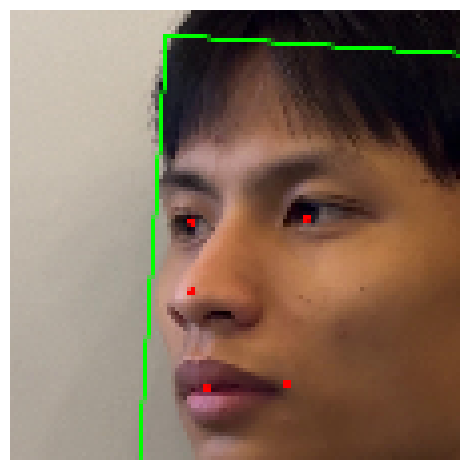

In [26]:
def visualize_affine_transform(img_path):
    # 1. Đọc ảnh
    img = cv2.imread(img_path)

    # 2. Phát hiện mặt và landmarks
    bboxes, landmarks = detector.detect(img)

    if len(bboxes) == 0:
        print("Không tìm thấy khuôn mặt nào!")
        return

    # 3. Chọn mặt lớn nhất để visualize
    idx = get_largest_face_idx(bboxes)
    landmark = landmarks[idx]

    for i in range(len(bboxes)):
        x1, y1, x2, y2 = bboxes[i][:4].astype(int)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 5)
        for pt in landmarks[i]:
            # THAM SỐ ĐIỀU CHỈNH: Thay đổi số 3 để chỉnh kích cỡ chấm đỏ
            cv2.circle(img, (int(pt[0]), int(pt[1])), 8, (0, 0, 255), -1)

    # 4. Thực hiện phép biến đổi Affine
    aligned_face = face_align.norm_crop(img, landmark=landmark)

    # Vẽ các đường tham chiếu chuẩn (tọa độ mắt thường ở y=38-40, miệng ở y=70-80)
    display_img = aligned_face.copy()
    cv2.line(display_img, (0, 40), (112, 40), (255, 0, 0), 1) # Đường ngang qua mắt
    cv2.line(display_img, (0, 80), (112, 80), (255, 0, 0), 1) # Đường ngang qua miệng
    cv2.line(display_img, (56, 0), (56, 112), (255, 0, 0), 1) # Đường dọc chính giữa

    # 5. Hiển thị
    plt.imshow(cv2.cvtColor(aligned_face, cv2.COLOR_BGR2RGB))
    # plt.title(f"Sau Affine Transform (Size: {aligned_face.shape[0]}x{aligned_face.shape[1]})")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

try:
    visualize_affine_transform(filename)
except NameError:
    print("Vui lòng chụp hoặc upload ảnh trước!")

### Chứng minh Affine Transform (Alignment)
Đoạn code này vẽ các đường lưới để bạn thấy rằng sau khi căn chỉnh, mắt và miệng luôn nằm ở các vị trí cố định (chuẩn diện).

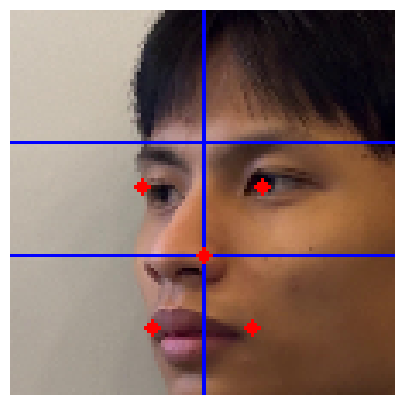

Giải thích: Trong ảnh 112x112, các điểm đỏ (landmarks) đã được đưa về vị trí chuẩn.
Bounding box không còn ý nghĩa ở đây vì toàn bộ ảnh 112x112 chính là vùng khuôn mặt.


In [27]:
def verify_alignment(img_path):
    img = cv2.imread(img_path)
    bboxes, landmarks = detector.detect(img)
    if len(bboxes) == 0: return

    idx = get_largest_face_idx(bboxes)
    # aligned_face là ảnh 112x112 đã được căn chỉnh
    aligned_face = face_align.norm_crop(img, landmark=landmarks[idx])

    display_img = aligned_face.copy()

    # 1. Vẽ các đường tham chiếu chuẩn (tọa độ pixel trên ảnh 112x112)
    cv2.line(display_img, (0, 38), (112, 38), (255, 0, 0), 1) # Đường ngang qua mắt chuẩn
    cv2.line(display_img, (0, 71), (112, 71), (255, 0, 0), 1) # Đường ngang qua miệng chuẩn
    cv2.line(display_img, (56, 0), (56, 112), (255, 0, 0), 1) # Đường dọc chính giữa

    # 2. Vị trí 5 điểm mốc chuẩn trong ảnh 112x112 của InsightFace
    # Đây là các tọa độ cố định mà hàm norm_crop luôn hướng tới
    standard_landmarks = np.array([
        [38.29, 51.69], # Mắt trái
        [73.53, 51.50], # Mắt phải
        [56.02, 71.73], # Mũi
        [41.54, 92.36], # Khóe miệng trái
        [70.72, 92.20]  # Khóe miệng phải
    ])

    for pt in standard_landmarks:
        cv2.circle(display_img, (int(pt[0]), int(pt[1])), 2, (0, 0, 255), -1)

    plt.figure(figsize=(5, 5))
    plt.imshow(cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

    print("Giải thích: Trong ảnh 112x112, các điểm đỏ (landmarks) đã được đưa về vị trí chuẩn.")
    print("Bounding box không còn ý nghĩa ở đây vì toàn bộ ảnh 112x112 chính là vùng khuôn mặt.")

try:
    verify_alignment(filename)
except NameError:
    print("Vui lòng upload ảnh trước!")

### Trực quan hóa Vector Embedding 512 chiều
Sau khi ảnh được căn chỉnh, ArcFace sẽ chuyển đổi nó thành một vector số thực gồm 512 phần tử đại diện cho đặc điểm khuôn mặt.

### Trực quan hóa quy trình: Ảnh gốc -> Căn chỉnh -> Embedding
Ô này giúp bạn thấy rõ đầu vào của bước trích xuất Vector chính là ảnh đã qua `norm_crop`.

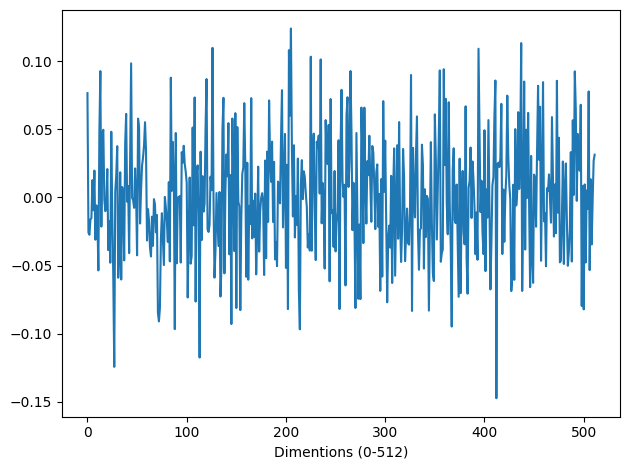

In [29]:
import matplotlib.pyplot as plt

def visualize_pipeline(img_path):
    # 1. Ảnh gốc
    img = cv2.imread(img_path)
    bboxes, landmarks = detector.detect(img)
    if len(bboxes) == 0: return

    idx = get_largest_face_idx(bboxes)
    landmark = landmarks[idx]

    for i in range(len(bboxes)):
        x1, y1, x2, y2 = bboxes[i][:4].astype(int)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        for pt in landmarks[i]:
            cv2.circle(img, (int(pt[0]), int(pt[1])), 3, (0, 0, 255), -1)

    # 2. Bước Norm Crop (Đầu vào của Recognition)
    aligned_face = face_align.norm_crop(img, landmark=landmark)

    # 3. Bước Trích xuất Embedding
    embedding = recognizer.align_and_extract(img, landmark)

    # # Hiển thị minh họa
    # fig = plt.figure(figsize=(15, 5))

    # # Cột 1: Ảnh gốc
    # plt.subplot(1, 3, 1)
    # plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    # plt.title("1. Ảnh gốc (Input)")
    # plt.axis('off')

    # # Cột 2: Ảnh đã căn chỉnh (Đây là cái model thực sự 'nhìn')
    # plt.subplot(1, 3, 2)
    # plt.imshow(cv2.cvtColor(aligned_face, cv2.COLOR_BGR2RGB))
    # plt.title("2. Aligned Face (112x112)\n(Đầu vào của ArcFace)")
    # plt.axis('off')

    # Cột 3: Vector Embedding (Dạng biểu đồ)
    # plt.subplot(1, 3, 3)
    plt.plot(embedding[:512]) # Vẽ 100 chiều đầu tiên cho rõ
    # plt.title("3. Vector Embedding\n(Đầu ra: 512 chiều)")
    plt.xlabel("Dimentions (0-512)")

    plt.tight_layout()
    plt.show()

try:
    visualize_pipeline(filename)
except NameError:
    print("Vui lòng chụp hoặc upload ảnh trước!")

### Trực quan hóa so khớp Cosine Similarity
Biểu đồ này hiển thị độ tương đồng giữa ảnh hiện tại và các danh tính trong cơ sở dữ liệu. Người có cột cao nhất (vượt ngưỡng threshold) sẽ được chọn làm danh tính cuối cùng.

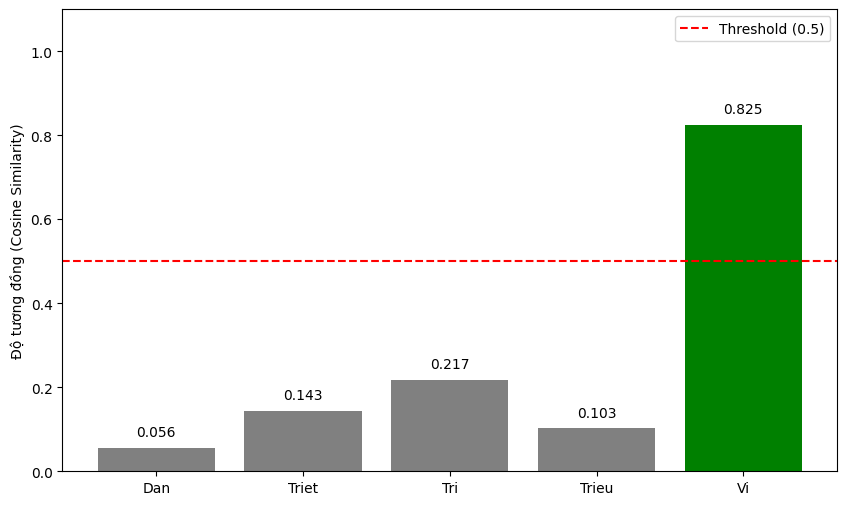

==> Kết quả: Nhận diện được là [Vi] với độ tin cậy 0.825


In [30]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_matching(img_path, database, threshold=0.5):
    # 1. Trích xuất embedding từ ảnh đầu vào
    img = cv2.imread(img_path)
    bboxes, landmarks = detector.detect(img)
    if len(bboxes) == 0:
        print("Không tìm thấy mặt!")
        return

    idx = get_largest_face_idx(bboxes)
    current_emb = recognizer.align_and_extract(img, landmarks[idx])

    # 2. Tính toán độ tương đồng với toàn bộ Database
    names = list(database.keys())
    similarities = []
    for name in names:
        sim = np.dot(current_emb, database[name])
        similarities.append(sim)

    # 3. Vẽ biểu đồ so sánh
    plt.figure(figsize=(10, 6))
    colors = ['green' if s == max(similarities) and s >= threshold else 'gray' for s in similarities]

    bars = plt.bar(names, similarities, color=colors)
    plt.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold ({threshold})')

    # plt.title(f"So khớp Cosine Similarity cho file: {img_path}")
    plt.ylabel("Độ tương đồng (Cosine Similarity)")
    plt.ylim(0, 1.1)
    plt.legend()

    # Thêm giá trị trên đầu mỗi cột
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.3f}', ha='center', va='bottom')

    plt.show()

    # Kết luận
    max_idx = np.argmax(similarities)
    if similarities[max_idx] >= threshold:
        print(f"==> Kết quả: Nhận diện được là [{names[max_idx]}] với độ tin cậy {similarities[max_idx]:.3f}")
    else:
        print("==> Kết quả: Unknown (Không có ai vượt ngưỡng threshold)")

try:
    # Sử dụng threshold 0.5 như các bước trước
    visualize_matching(filename, database, threshold=0.5)
except NameError:
    print("Vui lòng chụp hoặc upload ảnh trước!")

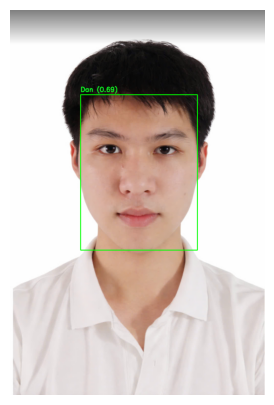

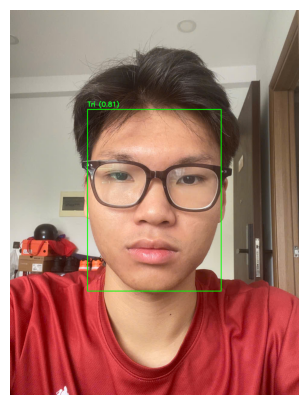

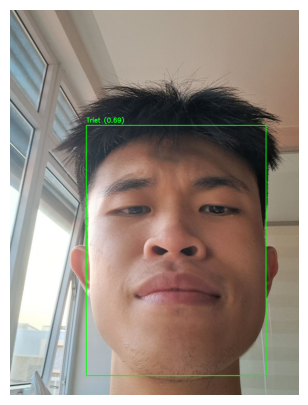

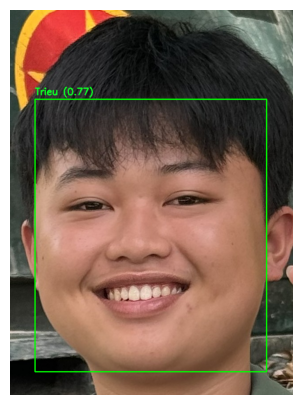

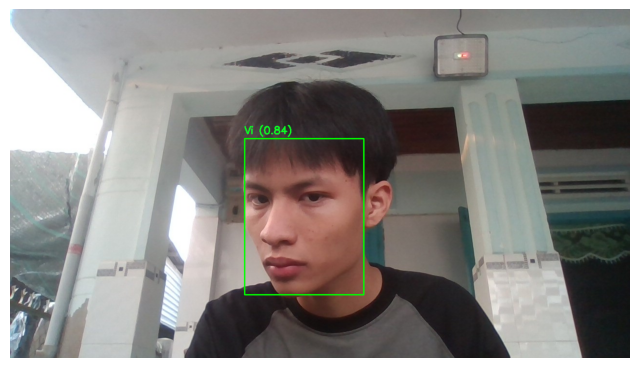

In [31]:
def visualize_test_set(test_path, database, threshold=0.5):
    # Lấy danh sách tên người từ các folder con trong test_path
    person_names = sorted([d for d in os.listdir(test_path) if os.path.isdir(os.path.join(test_path, d))])

    for name in person_names:
        person_dir = os.path.join(test_path, name)
        # Tìm ảnh đầu tiên trong folder của người đó
        files = [f for f in os.listdir(person_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        if not files:
            print(f"Không tìm thấy ảnh trong thư mục của {name}")
            continue

        # Lấy đường dẫn ảnh đầu tiên
        img_path = os.path.join(person_dir, files[1])
        frame = cv2.imread(img_path)

        if frame is None:
            continue

        # Sử dụng hàm nhận diện đã viết trước đó
        recognize_realtime(frame, database, threshold=threshold)

        # Hiển thị kết quả
        plt.figure(figsize=(8, 5))
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        # plt.title(f"Test Case: {name} (File: {files[0]})")
        plt.axis('off')
        plt.show()

# Thực thi visualize cho tập test
visualize_test_set(test_path, database)